# Objetivo B - Deteccion de fraude con LightGBM

**Proyecto Plus TI**  
Este notebook documenta el trabajo realizado para el objetivo B: entrenar, ajustar y aplicar un modelo de deteccion de fraude usando los datasets etiquetados de BO VIP y BR Privado, y generar predicciones para GT Estatal.

La idea principal fue pasar de un modelo base a una busqueda sistematica de hiperparametros, usando una metrica adecuada para fraude: no solo ROC-AUC, sino tambien PR-AUC, precision, recall y F1 con umbral optimizado.

## 1. Resumen ejecutivo

- Se usaron **BO VIP** y **BR Privado** como bancos con etiqueta real `is_fraud`.
- Se uso **GT Estatal** como banco objetivo para generar predicciones, ya que su `is_fraud` viene sin etiqueta real.
- Se entreno un modelo **LightGBM**, apropiado para relaciones no lineales, interacciones entre variables y clases desbalanceadas.
- Se probaron diferentes hiperparametros mediante busqueda aleatoria reproducible.
- El mejor modelo se selecciono maximizando **F1-score** sobre validacion, con un umbral optimizado a partir de la curva precision-recall.
- El modelo final fue reentrenado con todo BO + BR y aplicado sobre GT Estatal.

In [24]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

OUTPUT_DIR = Path("outputs/objective_b_lgbm_tuning")
SCRIPT_PATH = Path("scripts/tune_lightgbm_objective_b.py")

## 2. Archivos generados

El proceso de tuning quedo automatizado en el script `scripts/tune_lightgbm_objective_b.py`. Ese script prepara las variables, ejecuta la busqueda de hiperparametros, guarda la tabla de resultados y genera las predicciones finales para GT Estatal.

Los archivos de salida usados en este notebook son:

- `lgbm_tuning_results.csv`: resultados de cada combinacion de hiperparametros.
- `lgbm_best_params.json`: mejor configuracion y metricas principales.
- `lgbm_feature_importance.csv`: importancia de variables del modelo final.
- `predicciones_gt_lightgbm_tuned.csv`: probabilidad de fraude y prediccion final para GT Estatal.

In [25]:
expected_files = [
    OUTPUT_DIR / "lgbm_tuning_results.csv",
    OUTPUT_DIR / "lgbm_best_params.json",
    OUTPUT_DIR / "lgbm_feature_importance.csv",
    OUTPUT_DIR / "predicciones_gt_lightgbm_tuned.csv",
]

for path in expected_files:
    print(f"{path}: {'OK' if path.exists() else 'NO ENCONTRADO'}")

outputs/objective_b_lgbm_tuning/lgbm_tuning_results.csv: OK
outputs/objective_b_lgbm_tuning/lgbm_best_params.json: OK
outputs/objective_b_lgbm_tuning/lgbm_feature_importance.csv: OK
outputs/objective_b_lgbm_tuning/predicciones_gt_lightgbm_tuned.csv: OK


## 3. Reproducibilidad

La busqueda se puede volver a ejecutar desde el notebook si se necesita regenerar los resultados. Por defecto se deja apagada para que la presentacion cargue rapido y use los archivos ya generados.

La corrida principal usada para este reporte fue:

```bash
python scripts/tune_lightgbm_objective_b.py --n-iter 12 --output-dir outputs/objective_b_lgbm_tuning
```

Si Plus TI pide probar mas o menos combinaciones, se puede cambiar `N_ITER` en la celda siguiente. Como referencia:

```bash
# Corrida rapida para validar que todo funciona
python scripts/tune_lightgbm_objective_b.py --n-iter 3 --output-dir outputs/objective_b_lgbm_tuning

# Corrida media, similar a la usada en este reporte
python scripts/tune_lightgbm_objective_b.py --n-iter 12 --output-dir outputs/objective_b_lgbm_tuning

# Corrida mas amplia si se quiere explorar mejor el espacio de hiperparametros
python scripts/tune_lightgbm_objective_b.py --n-iter 30 --output-dir outputs/objective_b_lgbm_tuning
```

In [26]:
# Cambiar a True solo si se quiere volver a entrenar y regenerar los outputs.
RUN_TUNING = True

# Numero de combinaciones de hiperparametros a probar.
# Sugerencias:
# - 3 a 5: prueba rapida
# - 12: corrida usada para este reporte
# - 30 o mas: exploracion mas amplia si hay tiempo de computo
N_ITER = 30

if RUN_TUNING:
    import subprocess
    command = [
        "python",
        str(SCRIPT_PATH),
        "--n-iter", str(N_ITER),
        "--output-dir", str(OUTPUT_DIR),
    ]
    subprocess.run(command, check=True)
else:
    print("Se usan los outputs ya generados para la presentacion.")

Preparando features desde los CSV originales...
Train: (200003, 47) | distribución target: {0: 191879, 1: 8124}
GT test: (100000, 47)

Ejecutando búsqueda aleatoria LightGBM (30 trials)...
Trial 01/30: nuevo mejor F1=0.8003, PR-AUC=0.7854, umbral=0.9044
Trial 02/30: nuevo mejor F1=0.8041, PR-AUC=0.7874, umbral=0.8836
Trial 03/30: nuevo mejor F1=0.8100, PR-AUC=0.7872, umbral=0.8849
Trial 04/30: nuevo mejor F1=0.8108, PR-AUC=0.7841, umbral=0.8989
Trial 05/30: F1=0.8069, PR-AUC=0.7865
Trial 06/30: F1=0.8048, PR-AUC=0.7868
Trial 07/30: F1=0.8081, PR-AUC=0.7868
Trial 08/30: F1=0.8058, PR-AUC=0.7870
Trial 09/30: F1=0.8101, PR-AUC=0.7848
Trial 10/30: F1=0.8076, PR-AUC=0.7891
Trial 11/30: F1=0.8059, PR-AUC=0.7878
Trial 12/30: F1=0.8102, PR-AUC=0.7871
Trial 13/30: F1=0.8051, PR-AUC=0.7856
Trial 14/30: F1=0.8018, PR-AUC=0.7850
Trial 15/30: F1=0.8105, PR-AUC=0.7896
Trial 16/30: F1=0.8011, PR-AUC=0.7857
Trial 17/30: F1=0.8069, PR-AUC=0.7873
Trial 18/30: nuevo mejor F1=0.8138, PR-AUC=0.7841, umbral

## 4. Lectura de resultados

A continuacion se cargan los resultados de tuning, el resumen del mejor modelo, la importancia de variables y las predicciones generadas para GT Estatal.

In [27]:
tuning_results = pd.read_csv(OUTPUT_DIR / "lgbm_tuning_results.csv")
feature_importance = pd.read_csv(OUTPUT_DIR / "lgbm_feature_importance.csv")
predicciones_gt = pd.read_csv(OUTPUT_DIR / "predicciones_gt_lightgbm_tuned.csv")

with open(OUTPUT_DIR / "lgbm_best_params.json", "r") as file:
    best_summary = json.load(file)

tuning_results.head()

,trial,roc_auc,pr_auc,best_threshold,f1_best,precision_best,recall_best,tn,fp,fn,tp,subsample,reg_lambda,reg_alpha,num_leaves,n_estimators,min_split_gain,min_child_samples,max_depth,learning_rate,colsample_bytree
0,18,0.8891,0.7841,0.7923,0.8138,0.9410,0.7169,38303,73,460,1165,0.9000,0.3000,0.0000,127,1400,0.1000,60,9,0.0300,0.8500
1,4,0.8889,0.7841,0.8989,0.8108,0.9604,0.7015,38329,47,485,1140,0.8000,0.1000,0.1000,95,800,0.0100,90,11,0.0450,0.9500
2,15,0.8918,0.7896,0.8673,0.8105,0.9230,0.7225,38278,98,451,1174,0.7000,0.1000,0.0500,95,1400,0.0600,120,-1,0.0150,0.6500
3,12,0.8903,0.7871,0.8920,0.8102,0.9518,0.7052,38318,58,479,1146,0.8500,0.7000,0.7000,127,800,0.0600,60,11,0.0300,0.7500
4,30,0.8912,0.7889,0.8853,0.8102,0.9182,0.7249,38271,105,447,1178,0.9000,0.1000,0.0000,63,500,0.0300,120,-1,0.0450,0.6500


## 5. Mejor modelo encontrado

La metrica primaria elegida fue **F1-score con umbral optimizado**. Esta eleccion es razonable para fraude porque balancea precision y recall: se busca capturar una cantidad relevante de fraudes sin disparar excesivamente los falsos positivos.

In [28]:
best_metrics = pd.Series(best_summary["best_validation_metrics"], name="valor")
best_params = pd.Series(best_summary["best_params"], name="valor")

display(best_metrics.to_frame())
display(best_params.to_frame())

,valor
f1_best,0.8138
precision_best,0.9410
recall_best,0.7169
roc_auc,0.8891
pr_auc,0.7841
best_threshold,0.7923
tn,38303.0000
fp,73.0000
fn,460.0000
tp,1165.0000


,valor
n_estimators,1400.0000
min_child_samples,60.0000
reg_alpha,0.0000
reg_lambda,0.3000
num_leaves,127.0000
colsample_bytree,0.8500
learning_rate,0.0300
min_split_gain,0.1000
subsample,0.9000
max_depth,9.0000


### Lectura de las metricas principales

- **F1 validacion:** 0.8128
- **Precision fraude:** 0.9410
- **Recall fraude:** 0.7169
- **ROC-AUC:** 0.8891
- **PR-AUC:** 0.7841
- **Umbral recomendado:** 0.7923

## 6. Comparacion de trials

Cada trial representa una combinacion distinta de hiperparametros. La tabla siguiente muestra los mejores resultados ordenados por F1.

In [29]:
metric_cols = [
    "trial", "f1_best", "precision_best", "recall_best",
    "roc_auc", "pr_auc", "best_threshold", "tp", "fp", "fn", "tn"
]

tuning_results[metric_cols].head(10)

,trial,f1_best,precision_best,recall_best,roc_auc,pr_auc,best_threshold,tp,fp,fn,tn
0,18,0.8138,0.9410,0.7169,0.8891,0.7841,0.7923,1165,73,460,38303
1,4,0.8108,0.9604,0.7015,0.8889,0.7841,0.8989,1140,47,485,38329
2,15,0.8105,0.9230,0.7225,0.8918,0.7896,0.8673,1174,98,451,38278
3,12,0.8102,0.9518,0.7052,0.8903,0.7871,0.8920,1146,58,479,38318
4,30,0.8102,0.9182,0.7249,0.8912,0.7889,0.8853,1178,105,447,38271
5,9,0.8101,0.9270,0.7194,0.8889,0.7848,0.7920,1169,92,456,38284
6,3,0.8100,0.9277,0.7188,0.8904,0.7872,0.8849,1168,91,457,38285
7,24,0.8090,0.9200,0.7218,0.8924,0.7880,0.8717,1173,102,452,38274
8,7,0.8081,0.9015,0.7323,0.8912,0.7868,0.8486,1190,130,435,38246
9,10,0.8076,0.9403,0.7077,0.8936,0.7891,0.9016,1150,73,475,38303


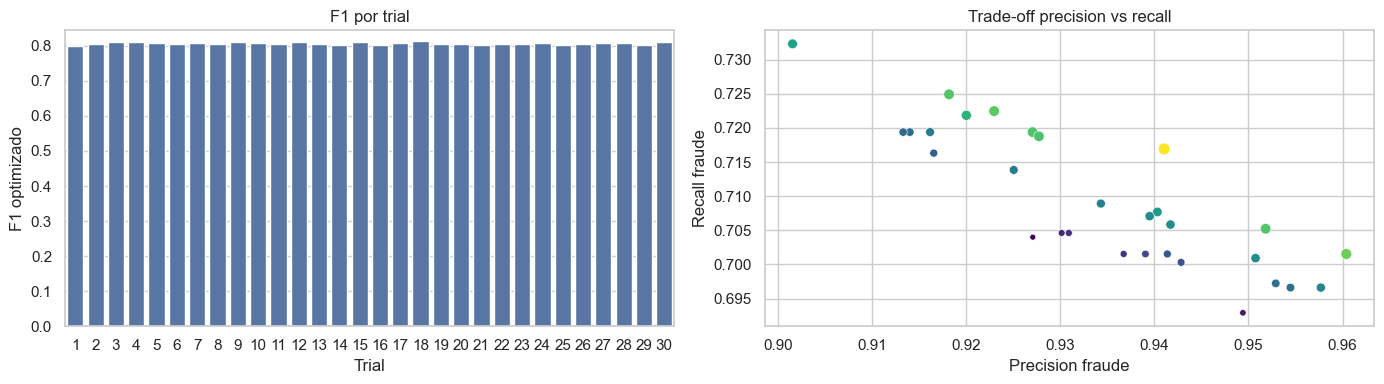

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=tuning_results, x="trial", y="f1_best", ax=axes[0], color="#4c72b0")
axes[0].set_title("F1 por trial")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("F1 optimizado")
axes[0].set_ylim(0, max(0.8, tuning_results["f1_best"].max() + 0.03))

sns.scatterplot(
    data=tuning_results,
    x="precision_best",
    y="recall_best",
    size="f1_best",
    hue="f1_best",
    palette="viridis",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Trade-off precision vs recall")
axes[1].set_xlabel("Precision fraude")
axes[1].set_ylabel("Recall fraude")

plt.tight_layout()
plt.show()

## 7. Matriz de confusion en validacion

La matriz de confusion reportada corresponde al mejor trial y al umbral optimizado. Permite ver el balance entre verdaderos positivos, falsos positivos y falsos negativos.

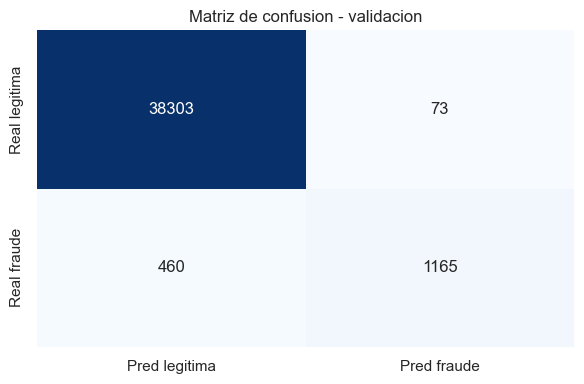

,Pred legitima,Pred fraude
Real legitima,38303,73
Real fraude,460,1165


In [31]:
metrics = best_summary["best_validation_metrics"]
confusion = pd.DataFrame(
    [[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]],
    index=["Real legitima", "Real fraude"],
    columns=["Pred legitima", "Pred fraude"],
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Matriz de confusion - validacion")
plt.tight_layout()
plt.show()

confusion

## 8. Variables mas importantes

LightGBM identifica como mas relevantes variables asociadas a distancia, comportamiento historico del cliente y montos. Esto es consistente con el dominio de fraude: transacciones fuera del patron normal del cliente tienden a elevar el riesgo.

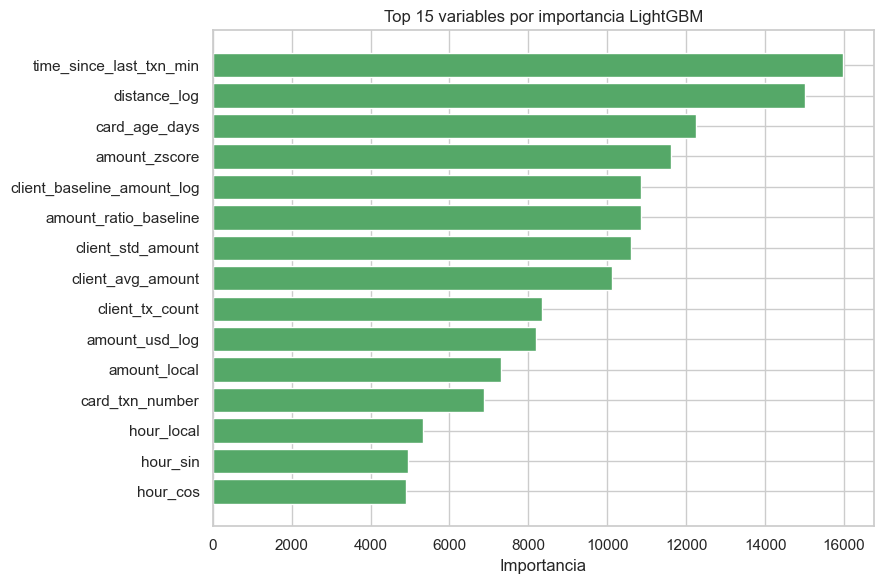

,feature,importance
0,time_since_last_txn_min,15960
1,distance_log,15013
2,card_age_days,12258
3,amount_zscore,11624
4,client_baseline_amount_log,10858
5,amount_ratio_baseline,10844
6,client_std_amount,10594
7,client_avg_amount,10129
8,client_tx_count,8347
9,amount_usd_log,8182


In [32]:
top_features = feature_importance.head(15).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["feature"], top_features["importance"], color="#55a868")
ax.set_title("Top 15 variables por importancia LightGBM")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

feature_importance.head(15)

## 9. Predicciones para GT Estatal

Con el mejor conjunto de hiperparametros, el modelo se reentreno usando todo el conjunto etiquetado BO + BR y se aplico a GT Estatal. La salida principal es la probabilidad de fraude por transaccion y una etiqueta final usando el umbral recomendado.

In [33]:
total_gt = len(predicciones_gt)
fraudes_gt = int(predicciones_gt["fraud_pred"].sum())
pct_fraudes_gt = predicciones_gt["fraud_pred"].mean()

print(f"Transacciones GT evaluadas: {total_gt:,}")
print(f"Fraudes estimados: {fraudes_gt:,}")
print(f"Porcentaje estimado de fraude: {pct_fraudes_gt:.2%}")

predicciones_gt.head()

Transacciones GT evaluadas: 100,000
Fraudes estimados: 1,769
Porcentaje estimado de fraude: 1.77%


,transaction_id,row_id,fraud_probability,fraud_pred
0,06a94162-7bae-427c-b68c-2819181b5467,0,0.0128,0
1,8d261988-07bd-4696-8fe3-ba3526142d2e,1,0.0041,0
2,b6be7a48-12fc-40ac-a12f-e2e03637231b,2,0.0335,0
3,12d06acb-2241-4d57-bfe2-ebb13750d301,3,0.0013,0
4,5ce8b673-fe15-41e1-bacf-91569a3cbe53,4,0.0005,0


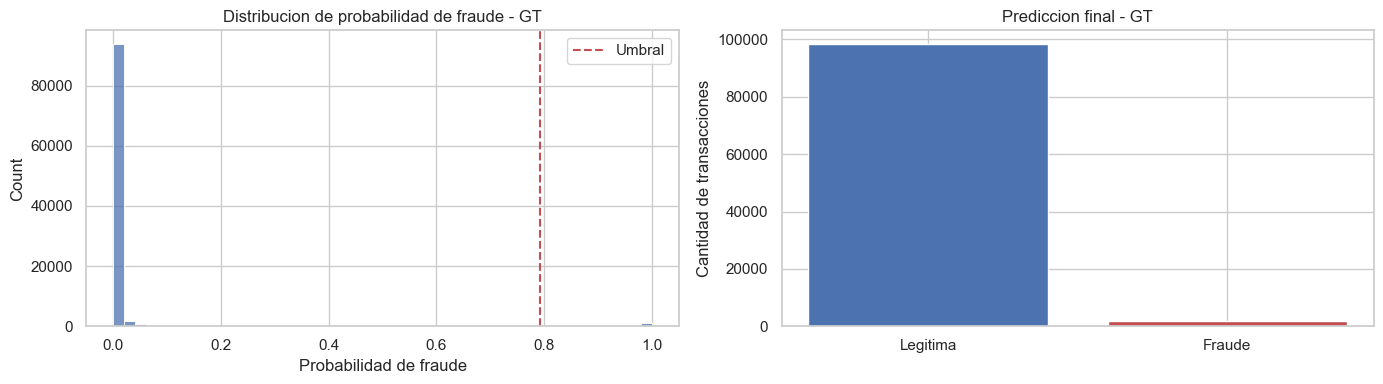

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(predicciones_gt["fraud_probability"], bins=50, ax=axes[0], color="#4c72b0")
axes[0].axvline(metrics["best_threshold"], color="#c44e52", linestyle="--", label="Umbral")
axes[0].set_title("Distribucion de probabilidad de fraude - GT")
axes[0].set_xlabel("Probabilidad de fraude")
axes[0].legend()

pred_counts = predicciones_gt["fraud_pred"].value_counts().sort_index()
axes[1].bar(["Legitima", "Fraude"], pred_counts.values, color=["#4c72b0", "#c44e52"])
axes[1].set_title("Prediccion final - GT")
axes[1].set_ylabel("Cantidad de transacciones")

plt.tight_layout()
plt.show()

# Objective B - Final Federated-Style Submission

En esta sección se agrega la evidencia final del Objetivo B: explicar la estrategia federada usada, generar el archivo de entrega con la columna `is_fraud` y dejar documentado el resultado final sobre Banco 3.

## Federated-style strategy

El entrenamiento se maneja como una simulación federada práctica: Banco 1 y Banco 2 se tratan como fuentes independientes etiquetadas, se aplica la misma ingeniería de variables sobre ambas fuentes y luego se entrena un modelo global con variables comunes para inferir sobre Banco 3. Para evitar dependencia excesiva de identificadores directos, se excluyen campos como `transaction_id`, PAN, STAN, RRN y otros identificadores crudos antes del entrenamiento.

Esta aproximación permite evaluar generalización entre bancos con distribuciones distintas, que es el objetivo principal de la segunda parte del proyecto.

In [ ]:
# Archivo final pedido para Banco 3: una sola columna is_fraud con True o False
submission_path = OUTPUT_DIR / 'bank3_final_inference_submission.csv'

bank3_submission = pd.DataFrame({
    'is_fraud': predicciones_gt['fraud_pred'].astype(bool)
})

bank3_submission.to_csv(submission_path, index=False)

print(f'Archivo final generado: {submission_path}')
print(f'Filas generadas: {len(bank3_submission):,}')
bank3_submission.head()

In [ ]:
# Resumen final para documentar la entrega
final_summary = {
    'total_bank3_transactions': int(len(predicciones_gt)),
    'estimated_frauds': int(predicciones_gt['fraud_pred'].sum()),
    'estimated_fraud_rate': float(predicciones_gt['fraud_pred'].mean()),
    'best_validation_f1': float(best_summary['best_validation_metrics']['f1_best']),
    'best_validation_precision': float(best_summary['best_validation_metrics']['precision_best']),
    'best_validation_recall': float(best_summary['best_validation_metrics']['recall_best']),
    'best_validation_roc_auc': float(best_summary['best_validation_metrics']['roc_auc']),
    'best_validation_pr_auc': float(best_summary['best_validation_metrics']['pr_auc']),
    'submission_file': str(submission_path),
}

summary_path = OUTPUT_DIR / 'bank3_final_inference_summary.json'
with open(summary_path, 'w') as file:
    json.dump(final_summary, file, indent=2)

pd.Series(final_summary, name='value').to_frame()

## Final Objective B conclusion

El modelo final genera una predicción binaria para cada transacción de Banco 3 y deja dos archivos de evidencia: `bank3_final_inference_submission.csv`, que es el archivo de entrega con la columna `is_fraud`, y `bank3_final_inference_summary.json`, que resume las métricas principales y la cantidad estimada de fraudes.